In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder


#https://www.kaggle.com/datasets/adilshamim8/student-performance-on-an-entrance-examination/data

#This dataset contains comprehensive information regarding candidates' performance in a common entrance examination, alongside various demographic and academic indicators. It is designed to support analysis into the factors influencing success in competitive exams and can serve as a valuable resource for educational researchers and data scientists.

#Key Features:
#Examination Performance: Data reflecting the candidate’s results in the entrance examination.
#Candidate Demographics:
#Sex: Gender of the candidate.
#Caste: Caste classification of the candidate.
#Coaching Details:
#Information on whether the candidate attended coaching classes within Assam, outside Assam, or did not attend any coaching.
#Educational Background:
#Board Details: Names of the boards where the candidate studied during Class X and Class XII.
#Medium of Instruction: The medium used for teaching during Class XII.
#Academic Performance:
#Class X Percentage: Marks secured at the Class X level.
#Class XII Percentage: Marks secured at the Class XII level.
#Parental Occupation:
#Occupation details for both the candidate's father and mother, which can help analyze socioeconomic influences on performance.

In [4]:
#print(os.listdir())
data = pd.read_csv('Capstone2/Student_Performance_on_an_Entrance_Examination.csv')
print(data.head())

  Gender    Caste coaching Class_ten_education twelve_education   medium  \
0   male  General       NO                SEBA            AHSEC  ENGLISH   
1   male      OBC       WA                SEBA            AHSEC   OTHERS   
2   male      OBC       OA              OTHERS             CBSE  ENGLISH   
3   male  General       WA                SEBA            AHSEC   OTHERS   
4   male  General       OA                SEBA             CBSE  ENGLISH   

  Class_X_Percentage Class_XII_Percentage Father_occupation Mother_occupation  \
0          Excellent            Excellent            DOCTOR            OTHERS   
1          Excellent            Excellent    SCHOOL_TEACHER        HOUSE_WIFE   
2          Excellent            Excellent          BUSINESS        HOUSE_WIFE   
3          Excellent            Excellent    SCHOOL_TEACHER    SCHOOL_TEACHER   
4          Excellent            Excellent   COLLEGE_TEACHER        HOUSE_WIFE   

  time Performance  
0  ONE   Excellent  
1  TWO   Excel

In [5]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 666 entries, 0 to 665
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Gender                666 non-null    object
 1   Caste                 666 non-null    object
 2   coaching              666 non-null    object
 3   Class_ten_education   666 non-null    object
 4   twelve_education      666 non-null    object
 5   medium                666 non-null    object
 6   Class_X_Percentage    666 non-null    object
 7   Class_XII_Percentage  666 non-null    object
 8   Father_occupation     666 non-null    object
 9   Mother_occupation     666 non-null    object
 10  time                  666 non-null    object
 11  Performance           666 non-null    object
dtypes: object(12)
memory usage: 62.6+ KB
None


In [6]:
GenderVals = data['Gender'].unique()
for column in data.columns:
    print(f"\nUnique value counts in '{column}':")
    print(data[column].value_counts(dropna=False))


Unique value counts in 'Gender':
Gender
male      355
female    311
Name: count, dtype: int64

Unique value counts in 'Caste':
Caste
General    329
OBC        162
ST         108
SC          67
Name: count, dtype: int64

Unique value counts in 'coaching':
coaching
WA    449
NO    150
OA     67
Name: count, dtype: int64

Unique value counts in 'Class_ten_education':
Class_ten_education
SEBA      396
CBSE      249
OTHERS     21
Name: count, dtype: int64

Unique value counts in 'twelve_education':
twelve_education
AHSEC     368
CBSE      290
OTHERS      8
Name: count, dtype: int64

Unique value counts in 'medium':
medium
ENGLISH     536
OTHERS       74
ASSAMESE     56
Name: count, dtype: int64

Unique value counts in 'Class_X_Percentage':
Class_X_Percentage
Excellent    511
Vg           101
Good          41
Average       13
Name: count, dtype: int64

Unique value counts in 'Class_XII_Percentage':
Class_XII_Percentage
Excellent    398
Vg           181
Good          75
Average       12
Name

In [7]:
print(data.head())

  Gender    Caste coaching Class_ten_education twelve_education   medium  \
0   male  General       NO                SEBA            AHSEC  ENGLISH   
1   male      OBC       WA                SEBA            AHSEC   OTHERS   
2   male      OBC       OA              OTHERS             CBSE  ENGLISH   
3   male  General       WA                SEBA            AHSEC   OTHERS   
4   male  General       OA                SEBA             CBSE  ENGLISH   

  Class_X_Percentage Class_XII_Percentage Father_occupation Mother_occupation  \
0          Excellent            Excellent            DOCTOR            OTHERS   
1          Excellent            Excellent    SCHOOL_TEACHER        HOUSE_WIFE   
2          Excellent            Excellent          BUSINESS        HOUSE_WIFE   
3          Excellent            Excellent    SCHOOL_TEACHER    SCHOOL_TEACHER   
4          Excellent            Excellent   COLLEGE_TEACHER        HOUSE_WIFE   

  time Performance  
0  ONE   Excellent  
1  TWO   Excel

In [8]:
missing = pd.concat([data.isnull().sum(), 100 * data.isnull().mean()], axis=1)
missing.columns=['count', '%']                  #label the two columns
missing.sort_values(by='count', ascending=False)

,count,%
Gender,0,0.0
Caste,0,0.0
coaching,0,0.0
Class_ten_education,0,0.0
twelve_education,0,0.0
medium,0,0.0
Class_X_Percentage,0,0.0
Class_XII_Percentage,0,0.0
Father_occupation,0,0.0
Mother_occupation,0,0.0


In [9]:
data.select_dtypes('object')

,Gender,Caste,coaching,Class_ten_education,twelve_education,medium,Class_X_Percentage,Class_XII_Percentage,Father_occupation,Mother_occupation,time,Performance
0,male,General,NO,SEBA,AHSEC,ENGLISH,Excellent,Excellent,DOCTOR,OTHERS,ONE,Excellent
1,male,OBC,WA,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,HOUSE_WIFE,TWO,Excellent
2,male,OBC,OA,OTHERS,CBSE,ENGLISH,Excellent,Excellent,BUSINESS,HOUSE_WIFE,TWO,Excellent
3,male,General,WA,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,SCHOOL_TEACHER,ONE,Excellent
4,male,General,OA,SEBA,CBSE,ENGLISH,Excellent,Excellent,COLLEGE_TEACHER,HOUSE_WIFE,TWO,Excellent
...,...,...,...,...,...,...,...,...,...,...,...,...
661,female,ST,WA,SEBA,AHSEC,ENGLISH,Good,Vg,OTHERS,HOUSE_WIFE,ONE,Average
662,male,ST,WA,SEBA,AHSEC,ENGLISH,Vg,Good,CULTIVATOR,HOUSE_WIFE,THREE,Average
663,male,ST,WA,SEBA,CBSE,ENGLISH,Good,Vg,OTHERS,SCHOOL_TEACHER,TWO,Average
664,male,ST,WA,SEBA,AHSEC,ENGLISH,Good,Good,SCHOOL_TEACHER,HOUSE_WIFE,THREE,Average


<Axes: title={'center': 'Performance'}, ylabel='Performance'>

<Figure size 640x480 with 0 Axes>

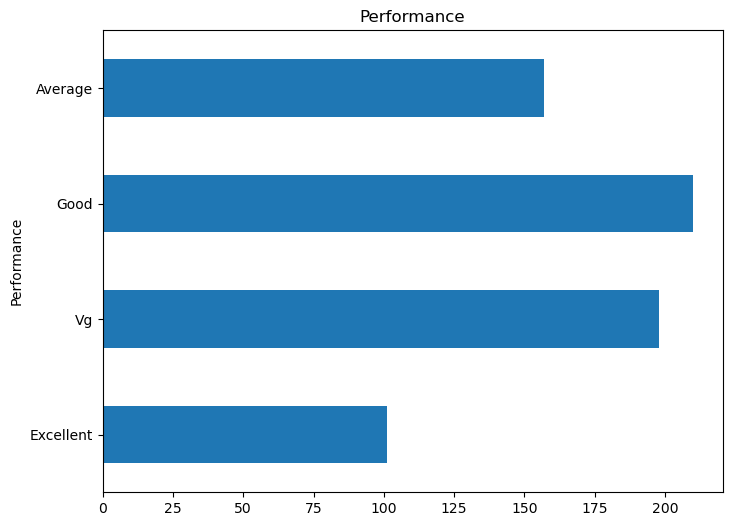

In [15]:
plt.clf()
custom_order = ['Excellent', 'Vg', 'Good', 'Average']

fig, ax = plt.subplots(figsize=(8, 6))  # Create a single plot
data.Performance.value_counts().reindex(custom_order).plot(kind='barh', ax=ax)
ax.set_title('Performance')
ax.set_xlabel('Count')

data.Performance.value_counts().reindex(custom_order).plot(kind='barh', ax=ax)

In [19]:
custom_order_map = {'Poor': 1, 'Average': 2, 'Good': 3, 'Excellent': 4}
data['Performance_map'] = data['Performance'].map(custom_order_map)


In [21]:
print(data)

     Gender    Caste coaching Class_ten_education twelve_education   medium  \
0      male  General       NO                SEBA            AHSEC  ENGLISH   
1      male      OBC       WA                SEBA            AHSEC   OTHERS   
2      male      OBC       OA              OTHERS             CBSE  ENGLISH   
3      male  General       WA                SEBA            AHSEC   OTHERS   
4      male  General       OA                SEBA             CBSE  ENGLISH   
..      ...      ...      ...                 ...              ...      ...   
661  female       ST       WA                SEBA            AHSEC  ENGLISH   
662    male       ST       WA                SEBA            AHSEC  ENGLISH   
663    male       ST       WA                SEBA             CBSE  ENGLISH   
664    male       ST       WA                SEBA            AHSEC  ENGLISH   
665  female       ST       NO                SEBA             CBSE  ENGLISH   

    Class_X_Percentage Class_XII_Percentage Father_

In [23]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 666 entries, 0 to 665
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gender                666 non-null    object 
 1   Caste                 666 non-null    object 
 2   coaching              666 non-null    object 
 3   Class_ten_education   666 non-null    object 
 4   twelve_education      666 non-null    object 
 5   medium                666 non-null    object 
 6   Class_X_Percentage    666 non-null    object 
 7   Class_XII_Percentage  666 non-null    object 
 8   Father_occupation     666 non-null    object 
 9   Mother_occupation     666 non-null    object 
 10  time                  666 non-null    object 
 11  Performance           666 non-null    object 
 12  Performance_map       468 non-null    float64
dtypes: float64(1), object(12)
memory usage: 67.8+ KB
None
